#  Speech Emotion Recognition (SER) using Deep Learning
> **An End-to-End PyTorch Pipeline for Audio Emotion Classification on the TESS Dataset**

---

###  Project Overview
Speech Emotion Recognition (SER) plays a crucial role in Human-Computer Interaction (HCI), AI voice assistants, and sentiment analysis. This notebook presents a complete deep learning workflow designed to process raw audio signals, extract spectral features via **Mel-Frequency Cepstral Coefficients (MFCCs)**, and classify emotions using a custom **2D Convolutional Neural Network (CNN)**.

####  Key Highlights:
* **Dataset**: TESS (Toronto Emotional Speech Set)
* **Framework**: PyTorch & Librosa
* **Features Extracted**: 20 MFCC Features padded/truncated to fixed length
* **Model**: Deep 2D CNN with BatchNorm, Dropout & Adaptive LR Scheduling
* **Performance**: ~99.5% Test Accuracy

---

##  1. Environment Setup & Dependencies
Importing essential libraries for data manipulation, audio signal processing, deep learning with PyTorch, and metrics calculation.

In [101]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import librosa.display
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import DataLoader , Dataset
import torchmetrics
from sklearn.metrics import confusion_matrix
import seaborn as sns
import joblib

##  2. Data Directory Configuration
Defining the base path for the TESS audio dataset stored within the Kaggle environment.

In [4]:
DATA_DIR = "/kaggle/input/datasets/ejlok1/toronto-emotional-speech-set-tess/tess toronto emotional speech set data/TESS Toronto emotional speech set data/"

##  3. Data Exploration & Class Inspection
Inspecting the directory structure to identify the target emotion categories and speaker folders present in the dataset.

In [5]:
classes = sorted(os.listdir(DATA_DIR))

print("Number of classes:", len(classes))
print("Classes:")
for cls in classes:
    print(cls)

Number of classes: 14
Classes:
OAF_Fear
OAF_Pleasant_surprise
OAF_Sad
OAF_angry
OAF_disgust
OAF_happy
OAF_neutral
YAF_angry
YAF_disgust
YAF_fear
YAF_happy
YAF_neutral
YAF_pleasant_surprised
YAF_sad


## 4. Dataset Parsing and DataFrame Construction
Traversing the dataset directory structure to collect all `.wav` audio file paths along with their corresponding speaker IDs and emotion labels, then organizing them into a Pandas DataFrame.

In [6]:
file_paths = []
speakers = []
emotions = []

for root,dirs,files in os.walk(DATA_DIR):
    folder = os.path.basename(root).split("_")
    for filename in files:
        if filename.endswith(".wav"):
            file_paths.append(os.path.join(root,filename))
            speakers.append(folder[0].lower())
            emotions.append(folder[1].lower())

data = {
    "file_paths" : file_paths,
    "speakers" : speakers,
    "emotions" : emotions
}

df = pd.DataFrame(data)


## 5. Dataset Inspection and Verification
Performing initial data sanity checks to verify the DataFrame structure, inspect sample rows, confirm total sample counts across features, and validate the unique target emotion classes.

In [7]:
print("DATA")
print("-" * 30)
print(df.head())
print("-" * 30)
print("LEN FILE PATHS")
print(len(file_paths))
print("LEN SPEAKERS")
print(len(speakers))
print("LEN EMOTIONS")
print(len(emotions))
print("-" * 30)
print("CLASSES")
print(set(emotions))
print("-" * 30)
print("EMOTIONS VALUE COUNTS")
print(df['emotions'].value_counts())

DATA
------------------------------
                                          file_paths speakers emotions
0  /kaggle/input/datasets/ejlok1/toronto-emotiona...      yaf     fear
1  /kaggle/input/datasets/ejlok1/toronto-emotiona...      yaf     fear
2  /kaggle/input/datasets/ejlok1/toronto-emotiona...      yaf     fear
3  /kaggle/input/datasets/ejlok1/toronto-emotiona...      yaf     fear
4  /kaggle/input/datasets/ejlok1/toronto-emotiona...      yaf     fear
------------------------------
LEN FILE PATHS
2800
LEN SPEAKERS
2800
LEN EMOTIONS
2800
------------------------------
CLASSES
{'fear', 'neutral', 'happy', 'angry', 'sad', 'disgust', 'pleasant'}
------------------------------
EMOTIONS VALUE COUNTS
emotions
fear        400
angry       400
disgust     400
neutral     400
sad         400
pleasant    400
happy       400
Name: count, dtype: int64


## 6. Speaker vs Emotion Class Distribution Analysis
Visualizing the cross-tabulation between speakers and emotion classes using a stacked bar chart to verify class balance and dataset symmetry across all actors.

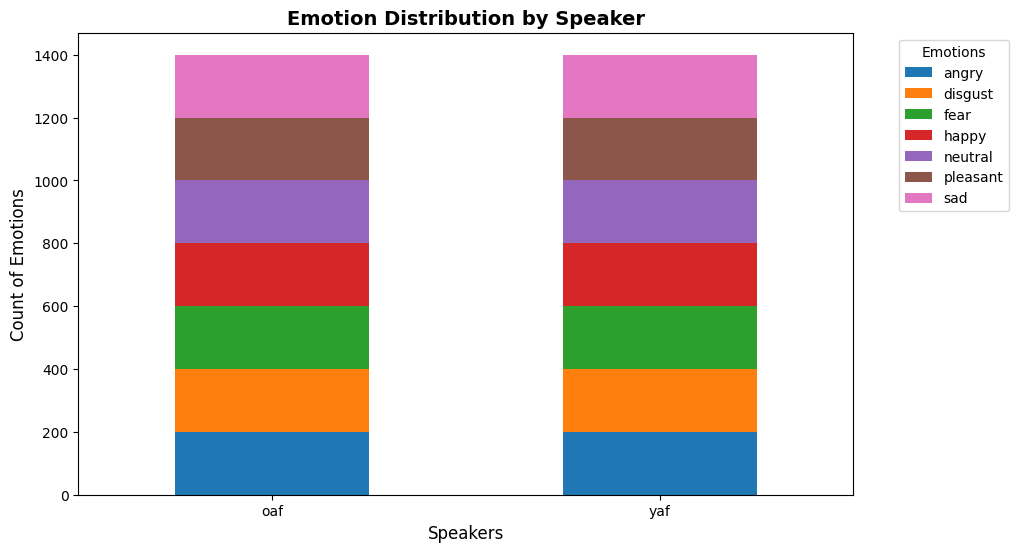

In [8]:
speaker_emotion = pd.crosstab(
    df['speakers'],
    df['emotions']
)

speaker_emotion.plot(kind='bar' ,stacked=True,figsize=(10,6))
plt.title('Emotion Distribution by Speaker', fontsize=14, fontweight='bold')
plt.xlabel('Speakers', fontsize=12)
plt.ylabel('Count of Emotions', fontsize=12)
plt.xticks(rotation=360)
plt.legend(title='Emotions', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

## 7. Exploratory Audio Signal Analysis (Waveform & Mel Spectrogram)
Visualizing raw time-domain audio signals (Waveforms) alongside their corresponding frequency-domain representations (Mel Spectrograms) across all 7 emotion classes to analyze amplitude, pitch variations, and spectral characteristics unique to each emotion.

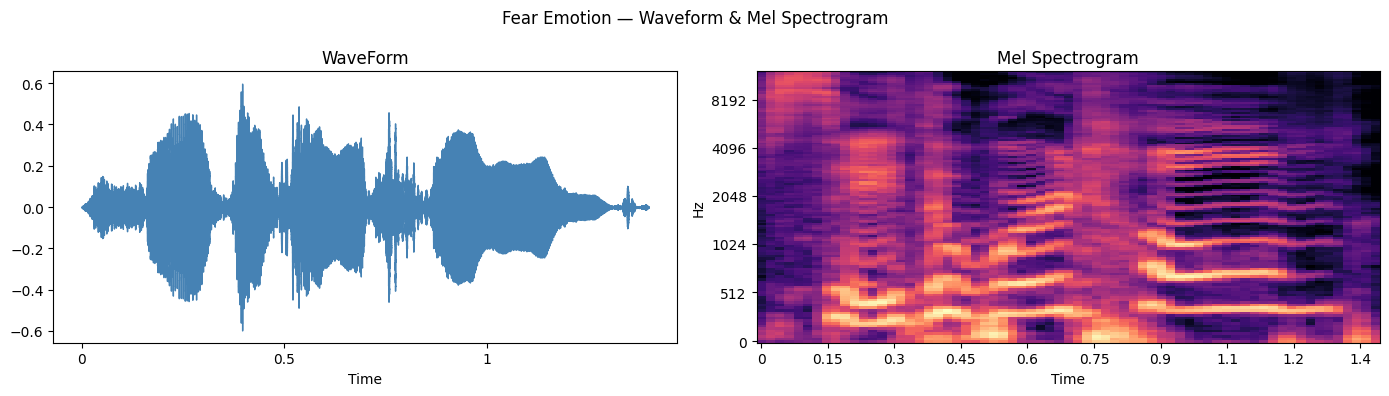

In [9]:
sample = df[df.emotions == 'fear'].iloc[0]

audio,sr = librosa.load(sample['file_paths'] , sr=None)

fig , ax = plt.subplots(1,2 , figsize=(14,4))
fig.suptitle("Fear Emotion — Waveform & Mel Spectrogram")
librosa.display.waveshow(audio,sr=sr, ax =ax[0] , color='steelblue')
ax[0].set_title('WaveForm')

mel_spec = librosa.feature.melspectrogram(y=audio,sr=sr)
mel_db = librosa.power_to_db(mel_spec,ref=np.max)
librosa.display.specshow(mel_db,sr=sr,x_axis='time' , y_axis='mel' , ax=ax[1])
ax[1].set_title("Mel Spectrogram")
plt.tight_layout()
plt.show()

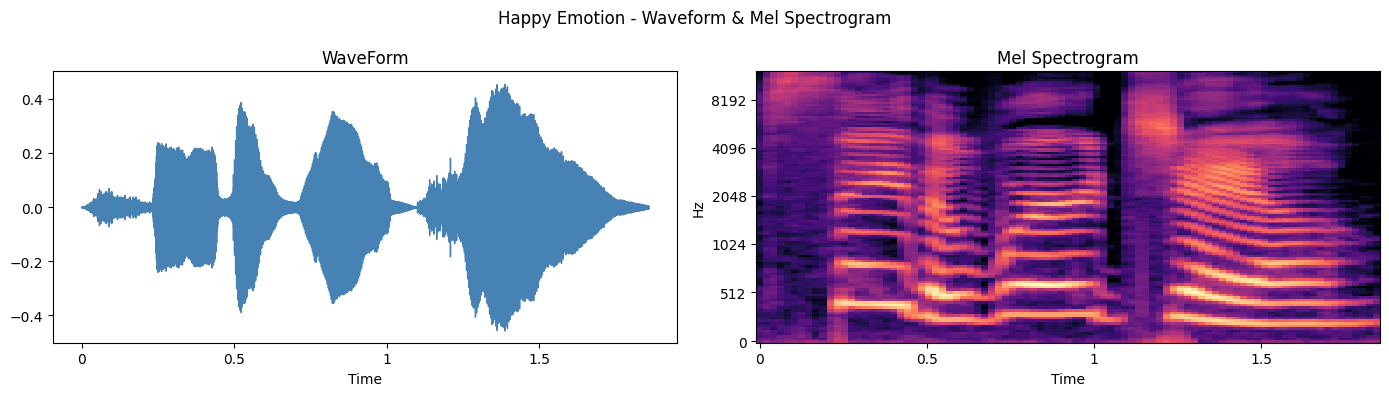

In [10]:
sample = df[df.emotions == 'happy'].iloc[0]

audio,sr = librosa.load(sample['file_paths'],sr=None)

fig,ax = plt.subplots(1,2,figsize=(14,4))
fig.suptitle("Happy Emotion - Waveform & Mel Spectrogram")
librosa.display.waveshow(audio,sr=sr,ax=ax[0],color='steelblue')
ax[0].set_title("WaveForm")

mel_spec = librosa.feature.melspectrogram(y=audio,sr=sr)
mel_db = librosa.power_to_db(mel_spec,ref=np.max)
librosa.display.specshow(mel_db,sr=sr,x_axis='time' , y_axis='mel' , ax=ax[1])
ax[1].set_title("Mel Spectrogram")
plt.tight_layout()
plt.show()

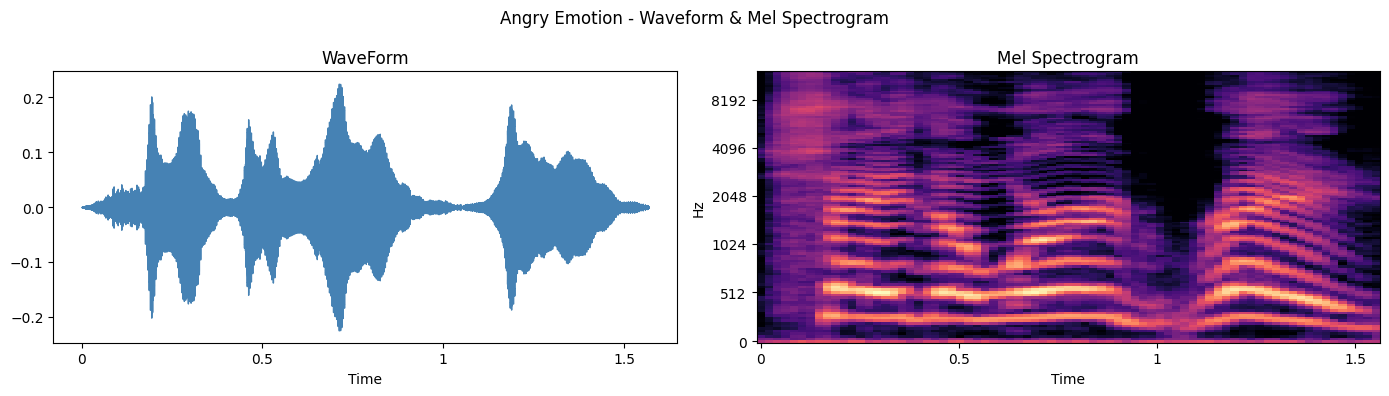

In [11]:
sample = df[df.emotions == 'angry'].iloc[0]

audio,sr = librosa.load(sample['file_paths'],sr=None)

fig,ax = plt.subplots(1,2,figsize=(14,4))
fig.suptitle("Angry Emotion - Waveform & Mel Spectrogram")
librosa.display.waveshow(audio,sr=sr,ax=ax[0],color='steelblue')
ax[0].set_title("WaveForm")

mel_spec = librosa.feature.melspectrogram(y=audio,sr=sr)
mel_db = librosa.power_to_db(mel_spec,ref=np.max)
librosa.display.specshow(mel_db,sr=sr,x_axis='time' , y_axis='mel' , ax=ax[1])
ax[1].set_title("Mel Spectrogram")
plt.tight_layout()
plt.show()

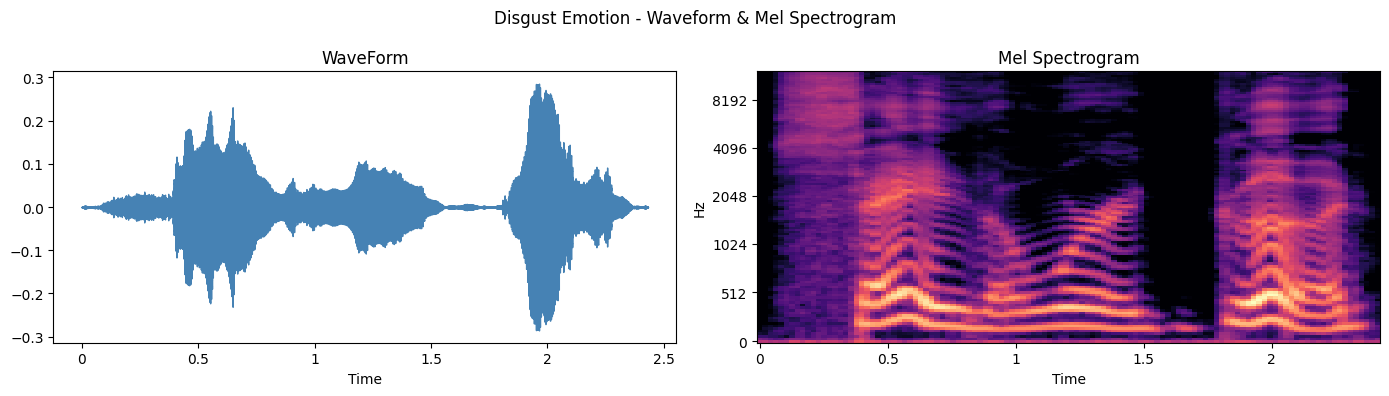

In [12]:
sample = df[df.emotions == 'disgust'].iloc[0]

audio,sr = librosa.load(sample['file_paths'],sr=None)

fig,ax = plt.subplots(1,2,figsize=(14,4))
fig.suptitle("Disgust Emotion - Waveform & Mel Spectrogram")
librosa.display.waveshow(audio,sr=sr,ax=ax[0],color='steelblue')
ax[0].set_title("WaveForm")

mel_spec = librosa.feature.melspectrogram(y=audio,sr=sr)
mel_db = librosa.power_to_db(mel_spec,ref=np.max)
librosa.display.specshow(mel_db,sr=sr,x_axis='time' , y_axis='mel' , ax=ax[1])
ax[1].set_title("Mel Spectrogram")
plt.tight_layout()
plt.show()

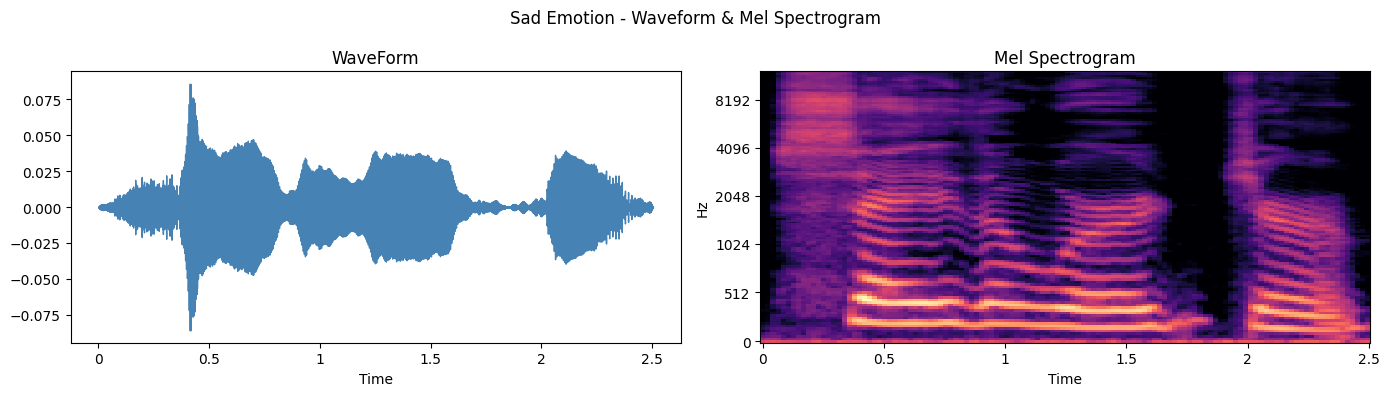

In [13]:
sample = df[df.emotions == 'sad'].iloc[0]

audio,sr = librosa.load(sample['file_paths'],sr=None)

fig,ax = plt.subplots(1,2,figsize=(14,4))
fig.suptitle("Sad Emotion - Waveform & Mel Spectrogram")
librosa.display.waveshow(audio,sr=sr,ax=ax[0],color='steelblue')
ax[0].set_title("WaveForm")

mel_spec = librosa.feature.melspectrogram(y=audio,sr=sr)
mel_db = librosa.power_to_db(mel_spec,ref=np.max)
librosa.display.specshow(mel_db,sr=sr,x_axis='time' , y_axis='mel' , ax=ax[1])
ax[1].set_title("Mel Spectrogram")
plt.tight_layout()
plt.show()

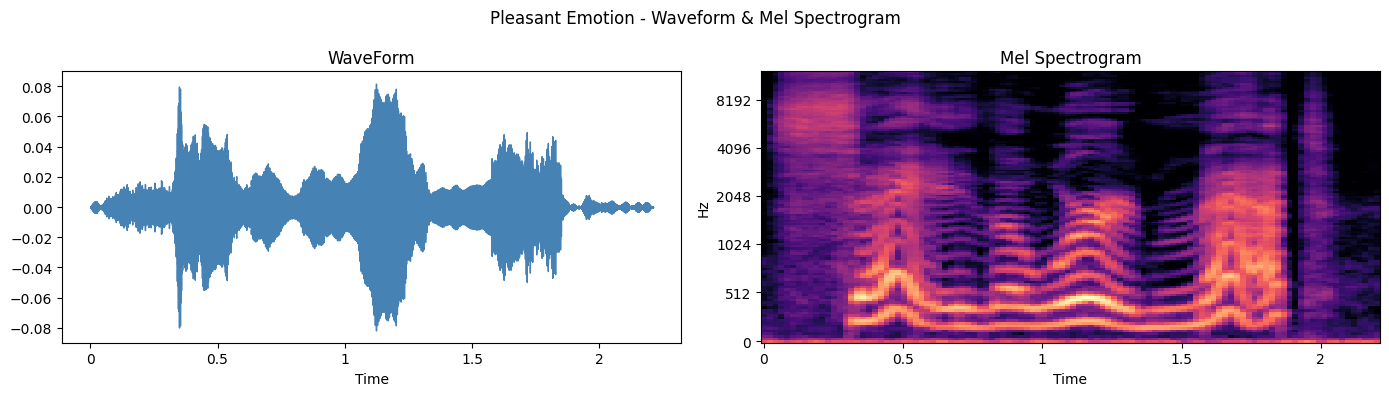

In [14]:
sample = df[df.emotions == 'pleasant'].iloc[0]

audio,sr = librosa.load(sample['file_paths'],sr=None)

fig,ax = plt.subplots(1,2,figsize=(14,4))
fig.suptitle("Pleasant Emotion - Waveform & Mel Spectrogram")
librosa.display.waveshow(audio,sr=sr,ax=ax[0],color='steelblue')
ax[0].set_title("WaveForm")

mel_spec = librosa.feature.melspectrogram(y=audio,sr=sr)
mel_db = librosa.power_to_db(mel_spec,ref=np.max)
librosa.display.specshow(mel_db,sr=sr,x_axis='time' , y_axis='mel' , ax=ax[1])
ax[1].set_title("Mel Spectrogram")
plt.tight_layout()
plt.show()

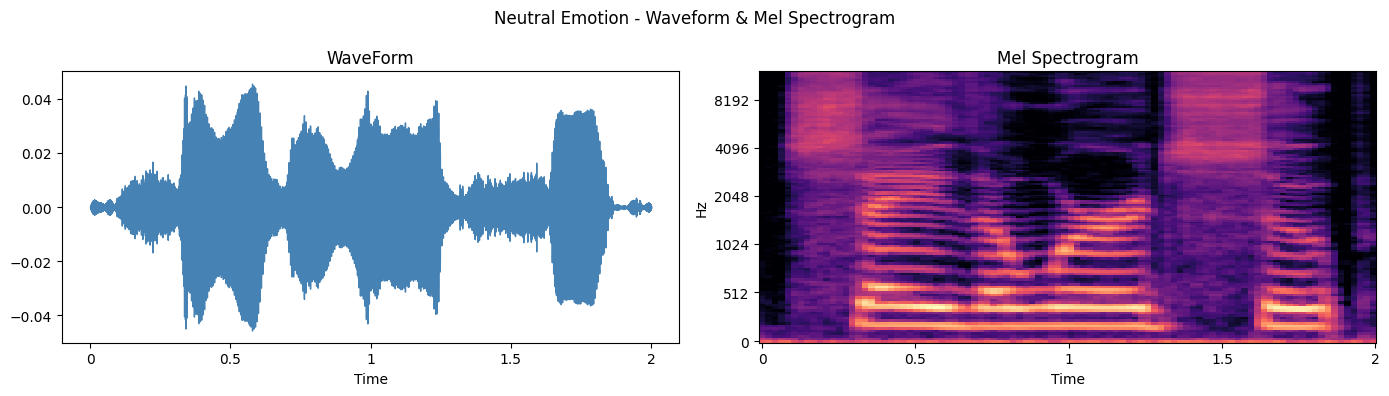

In [15]:
sample = df[df.emotions == 'neutral'].iloc[0]

audio,sr = librosa.load(sample['file_paths'],sr=None)

fig,ax = plt.subplots(1,2,figsize=(14,4))
fig.suptitle("Neutral Emotion - Waveform & Mel Spectrogram")
librosa.display.waveshow(audio,sr=sr,ax=ax[0],color='steelblue')
ax[0].set_title("WaveForm")

mel_spec = librosa.feature.melspectrogram(y=audio,sr=sr)
mel_db = librosa.power_to_db(mel_spec,ref=np.max)
librosa.display.specshow(mel_db,sr=sr,x_axis='time' , y_axis='mel' , ax=ax[1])
ax[1].set_title("Mel Spectrogram")
plt.tight_layout()
plt.show()

## 8. Audio Feature Extraction (MFCC Padding & Truncation)
Defining a feature extraction function that computes 20 Mel-Frequency Cepstral Coefficients (MFCCs) for each audio file and standardizes feature dimensions to a fixed length using zero-padding or truncation.

In [16]:
def mfcc(file_path,max_len = 174):
    audio , sr = librosa.load(file_path , sr=None)

    mfcc = librosa.feature.mfcc(y=audio , sr=sr)

    if mfcc.shape[1] < max_len:
        mfcc =  np.pad(mfcc , ((0,0) , (0 , max_len-mfcc.shape[1])), mode = "constant")

    else:
        mfcc = mfcc[: , :max_len]

    return mfcc

## 9. Stratified Dataset Splitting
Splitting the dataset into Training (70%), Validation (15%), and Test (15%) subsets using stratified sampling to ensure equal emotion class distributions across all sets.

In [17]:
train_df,temp_df = train_test_split(
    df,
    test_size = 0.3,
    random_state = 42,
    stratify=df['emotions']
)

val_df,test_df = train_test_split(
    temp_df,
    test_size = 0.5,
    random_state=42,
    stratify=temp_df['emotions']
)

print("LEN TRAIN :" , len(train_df))
print("LEN VAL :" , len(val_df))
print("LEN TEST :" , len(test_df))

LEN TRAIN : 1960
LEN VAL : 420
LEN TEST : 420


## 10. Batch Feature Extraction Pipeline
Defining a helper function to iterate through all file paths in a given dataset split and extract their MFCC feature matrices sequentially.

In [18]:
def extract_features(df):
    features = []

    for path in df['file_paths']:
        feature = mfcc(path)
        features.append(feature)

    return features

## 11. Extracting Features across Splits
Executing feature extraction across the Training, Validation, and Test DataFrames to create the input feature arrays (X) and target label vectors (y).

In [19]:
X_train = extract_features(train_df)
y_train = train_df['emotions']

X_test = extract_features(test_df)
y_test = test_df['emotions']

X_val = extract_features(val_df)
y_val = val_df['emotions']

## 12. Feature-Label Dimension Validation
Verifying that the total number of extracted feature instances strictly matches the target label count for each dataset split before building PyTorch DataLoaders.

In [20]:
if len(X_train) == len(y_train):
    print(len(X_train))

if len(X_test) == len(y_test):
    print(len(X_test))

if len(X_val) == len(y_val):
    print(len(X_val))

1960
420
420


## 13. Label Encoding
Encoding categorical emotion labels into numerical values using Scikit-Learn's `LabelEncoder`, fitting strictly on the training set to prevent data leakage and transforming validation and test sets accordingly.

In [21]:
encoder = LabelEncoder()

y_train_encoded = encoder.fit_transform(y_train)

y_test_encoded = encoder.transform(y_test)

y_val_encoded = encoder.transform(y_val)

## 14. Label Mapping and Encoding Verification
Inspecting the mapped class indices against the original target emotion names and reviewing sample encoded arrays across all splits.

In [22]:
print(encoder.classes_)

print(y_train_encoded[:10])
print(y_test_encoded[:10])
print(y_val_encoded[:10])

['angry' 'disgust' 'fear' 'happy' 'neutral' 'pleasant' 'sad']
[3 4 6 6 2 0 2 6 5 3]
[1 5 2 2 6 6 4 3 2 4]
[4 3 5 1 6 4 0 1 4 2]


## 15. Feature Shape Consistency Check
Verifying that all extracted MFCC feature matrices maintain consistent 2D dimensions `(20, 174)` across train, validation, and test sets.

In [23]:
set(feature.shape for feature in X_train)
set(feature.shape for feature in X_val)
set(feature.shape for feature in X_test)

{(20, 174)}

## 16. Custom PyTorch Dataset Definition
Implementing a custom PyTorch `Dataset` class (`SpeechDataset`) to handle feature tensor conversions, label casting, and batch indexing on the target device.

In [112]:
class SpeechDataset(Dataset):
    def __init__(self,x,y,device):
        self.x = torch.tensor(x, dtype=torch.float32).to(device)
        self.y = torch.tensor(y, dtype=torch.long).to(device)

    def __len__(self):
        return len(self.x)

    def __getitem__(self,idx):
        x = self.x[idx]
        y = self.y[idx]

        return x , y

device = torch.device("cuda" if torch.cuda.is_available() else 'cpu')

train_dataset = SpeechDataset(x=X_train , y=y_train_encoded,device=device)
test_dataset = SpeechDataset(x=X_test , y=y_test_encoded,device=device)
val_dataset = SpeechDataset(x=X_val , y=y_val_encoded,device=device)
#----------------
train_loader = DataLoader(dataset=train_dataset , batch_size=64 , shuffle=True)
test_loader = DataLoader(dataset=test_dataset,batch_size=64 , shuffle=False)
val_loader = DataLoader(dataset=val_dataset , batch_size=64 , shuffle=False)

In [35]:
x_batch , y_batch = next(iter(train_loader))
print(x_batch.shape)
print(y_batch.shape)

torch.Size([64, 20, 174])
torch.Size([64])


## 17. Deep 2D CNN Architecture & Weight Initialization
Defining the core `SpeechNN` model architecture utilizing stacked 2D Convolutional blocks (`nn.Conv2d`), Batch Normalization (`nn.BatchNorm2d`), ReLU activations, and Max Pooling layers. Kaiming Normal initialization (`nn.init.kaiming_normal_`) is applied to convolutional weights to support stable gradient flow across training epochs.

In [36]:
class SpeechNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.block1 = nn.Sequential(
            nn.Conv2d(
                in_channels=1 ,
                out_channels = 32 ,
                kernel_size = 3 ,
                stride=1 ,
                padding=1
            ),

            nn.BatchNorm2d(num_features = 32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,stride=2)
        )

        nn.init.kaiming_normal_(self.block1[0].weight ,a=0 , mode='fan_in' , nonlinearity='relu')
        if self.block1[0].bias is not None :
            nn.init.constant_(self.block1[0].bias , 0.0)


        self.block2 = nn.Sequential(
            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size = 3,
                stride=1,
                padding = 1
            ),
            nn.BatchNorm2d(num_features = 64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2 , stride=2)
        )

        nn.init.kaiming_normal_(self.block2[0].weight , a=0,mode='fan_in' , nonlinearity='relu')
        if self.block2[0].bias is not None:
            nn.init.constant_(self.block2[0].bias , 0.0)

        self.block3 = nn.Sequential(
            nn.Conv2d(
                in_channels=64,
                out_channels=128,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.BatchNorm2d(num_features = 128),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(output_size=(1,1))
        )

        nn.init.kaiming_normal_(self.block3[0].weight , a=0 , mode='fan_in' , nonlinearity='relu')
        if self.block3[0].bias is not None:
            nn.init.constant_(self.block3[0].bias , 0.0)


        self.block4 = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128,64),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            nn.Linear(64,7)
            
        )
        
        nn.init.kaiming_normal_(self.block4[1].weight , a=0 , mode='fan_in' , nonlinearity='relu')
        if self.block4[1].bias is not None:
            nn.init.constant_(self.block4[1].bias , 0.0)


    def forward(self,x):
        x = x.unsqueeze(1)
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        
        return x


## 18. Training and Validation Pipeline Implementation
Constructing the main `train_val_model` pipeline handling iterative training loops, backpropagation, gradient clipping (`nn.utils.clip_grad_value_`), and metric tracking for loss and accuracy using `torchmetrics` across training and validation splits.

In [114]:
def train_val_model(model,optimizer,criterion,train_loader,val_loader,epochs,scheduler):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    history = {
        "loss" : [],
        'accuracy' : [],
        "val_accuracy" : [],
        "val_loss" : []
    }
    for epoch in range(epochs):
        model.train()
        total_train_loss = 0.0
        train_accuracy = torchmetrics.classification.MulticlassAccuracy(num_classes=7).to(device)

        for features,labels in train_loader:
            
            features = features.to(device)
            
            labels = labels.to(device)
            
            optimizer.zero_grad()
            
            output = model(features).to(device)
            
            loss = criterion(output,labels).to(device)
            
            loss.backward()
            
            nn.utils.clip_grad_value_(model.parameters() , clip_value=1.0)
            
            optimizer.step()
            
            total_train_loss +=  loss.item()
            train_accuracy(output,labels)

        
        model.eval()
        with torch.inference_mode():
            total_val_loss = 0.0
            val_accuracy = torchmetrics.classification.MulticlassAccuracy(num_classes=7).to(device)
            for features,labels in val_loader:
                
                features = features.to(device)
                
                labels = labels.to(device)
                
                output = model(features).to(device)
                
                loss = criterion(output,labels).to(device)
                
                total_val_loss += loss.item()
                
                val_accuracy(output,labels)

        avg_train_loss = total_train_loss / len(train_loader)
        avg_val_loss = total_val_loss / len(val_loader)
        scheduler.step(avg_val_loss)

        final_accuracy_val = val_accuracy.compute().cpu().item() * 100
        final_accuracy_train = train_accuracy.compute().cpu().item() * 100

        
        history['loss'].append(avg_train_loss)
        history['accuracy'].append(final_accuracy_train)
        history['val_loss'].append(avg_val_loss)
        history['val_accuracy'].append(final_accuracy_val)

        val_accuracy.reset()
        train_accuracy.reset()

        print(f"Epoch :{epoch+1}|"
             f"Train_loss :{avg_train_loss:.2f}|"
            f"Train_accuracy :{final_accuracy_train:.2f}|"
            f"Val_loss : {avg_val_loss:.2f}|"
            f"Val_accuracy :{final_accuracy_val:.2f}")
        
    return history

## 19. Model Initialization & Hyperparameter Configuration
Instantiating the `SpeechNN` model, setting up the `AdamW` optimizer with weight decay, configuring `CrossEntropyLoss`, and defining a `ReduceLROnPlateau` learning rate scheduler to adjust the learning rate dynamically based on validation performance.

In [115]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SpeechNN().to(device)
optimizer = optim.AdamW(model.parameters(), lr=0.0005, weight_decay=0.01)
loss = nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
print(device)

cuda


## 20. Executing Model Training & Validation
Running the training loop across 10 epochs while logging training/validation loss and accuracy metrics to monitor convergence and generalization.

In [118]:
train_val = train_val_model(
    model=model,
    optimizer=optimizer,
    criterion=loss,
    train_loader=train_loader,
    val_loader=val_loader,
    scheduler=scheduler,
    epochs=10
)

Epoch :1|Train_loss :0.07|Train_accuracy :98.83|Val_loss : 0.08|Val_accuracy :98.57
Epoch :2|Train_loss :0.05|Train_accuracy :99.23|Val_loss : 0.04|Val_accuracy :99.76
Epoch :3|Train_loss :0.05|Train_accuracy :99.34|Val_loss : 0.05|Val_accuracy :99.05
Epoch :4|Train_loss :0.05|Train_accuracy :99.29|Val_loss : 0.08|Val_accuracy :97.38
Epoch :5|Train_loss :0.04|Train_accuracy :99.49|Val_loss : 0.10|Val_accuracy :97.86
Epoch :6|Train_loss :0.05|Train_accuracy :99.23|Val_loss : 0.40|Val_accuracy :82.62
Epoch :7|Train_loss :0.03|Train_accuracy :99.69|Val_loss : 0.03|Val_accuracy :99.52
Epoch :8|Train_loss :0.04|Train_accuracy :99.49|Val_loss : 0.08|Val_accuracy :97.38
Epoch :9|Train_loss :0.03|Train_accuracy :99.59|Val_loss : 0.02|Val_accuracy :99.52
Epoch :10|Train_loss :0.03|Train_accuracy :99.64|Val_loss : 0.02|Val_accuracy :99.76


## 21. Validation Evaluation & Confusion Matrix Visualization
Evaluating the model on the validation set to generate a Confusion Matrix, assessing per-class classification accuracy and identifying any misclassification patterns across emotion categories.

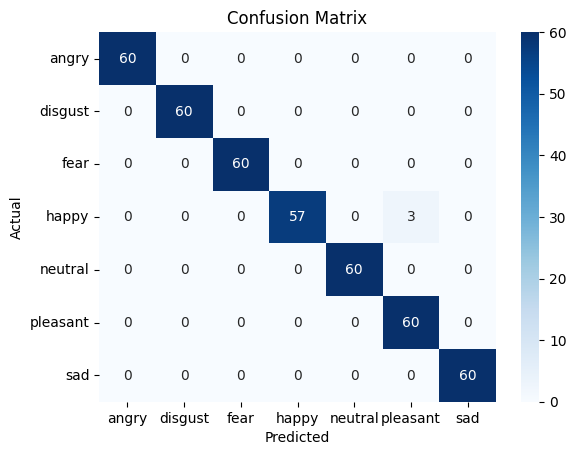

In [89]:
def confusionm(model,val_loader):
    with torch.inference_mode():
        
        model.eval()
        all_labels = []
        all_preds = []
        for features,labels in val_loader:
            output = model(features)
            pred = torch.argmax(output,dim=1)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(pred.cpu().numpy())
        
        cm = confusion_matrix(all_labels,all_preds)
        return cm

cm = confusionm(model=model,val_loader=val_loader)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_,
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## 22. Training and Validation Learning Curves
Plotting training versus validation Accuracy and Loss trajectories across epochs to visually evaluate model stability, learning convergence, and check for potential overfitting or underfitting.

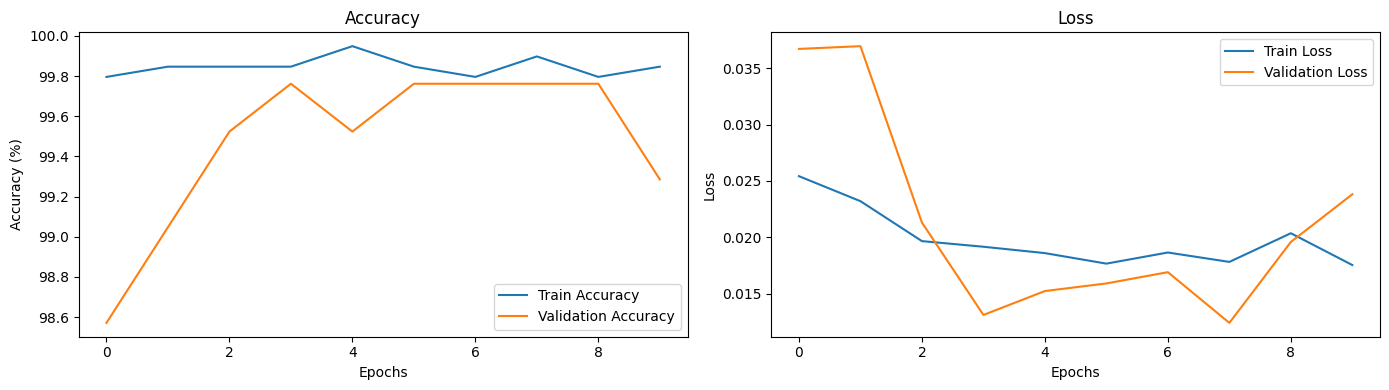

In [95]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(train_val["accuracy"], label="Train Accuracy")
axes[0].plot(train_val["val_accuracy"], label="Validation Accuracy")
axes[0].set_title("Accuracy")
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("Accuracy (%)")
axes[0].legend()

axes[1].plot(train_val["loss"], label="Train Loss")
axes[1].plot(train_val["val_loss"], label="Validation Loss")
axes[1].set_title("Loss")
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.show()


## 23. Final Model Evaluation on Unseen Test Data
Evaluating the trained model on the held-out test dataset (`test_loader`) to compute the final unbiased test loss and overall test accuracy using `torchmetrics`.

In [100]:
def test_model(model, criterion, test_loader):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()
    
    total_test_loss = 0.0
    test_accuracy = torchmetrics.classification.MulticlassAccuracy(num_classes=7).to(device)
    
    with torch.inference_mode():
        for features, labels in test_loader:
            features, labels = features.to(device), labels.to(device)
            
            output = model(features)
            loss = criterion(output, labels)
            
            total_test_loss += loss.item()
            test_accuracy(output, labels)
            
    avg_test_loss = total_test_loss / len(test_loader)
    final_test_acc = test_accuracy.compute().item() * 100
    
    print(f"Test Loss: {avg_test_loss:.4f} | Test Accuracy: {final_test_acc:.2f}")


test_model(model, loss, test_loader)

Test Loss: 0.0130 | Test Accuracy: 99.52


## 24. Test Set Predictions Extraction
Running inference across the test dataset to collect ground-truth labels and model predictions for detailed post-evaluations and classification reporting.

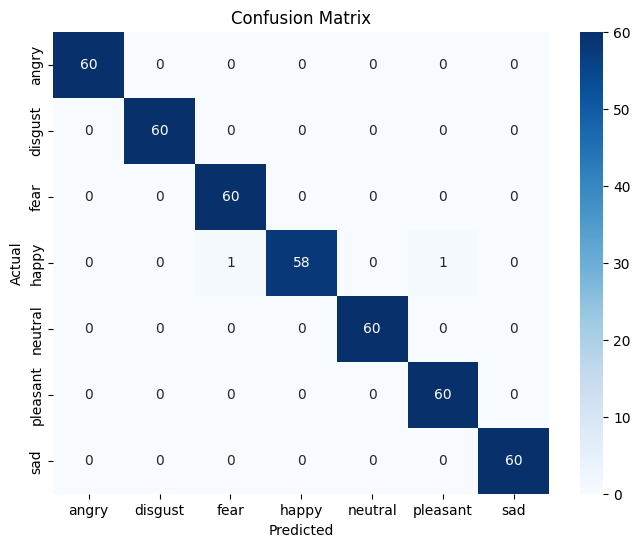

In [105]:
model.eval()
all_preds, all_labels = [], []

with torch.inference_mode():
    for features, labels in test_loader:
        features = features.to(device)
        outputs = model(features)
        preds = torch.argmax(outputs, dim=1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=encoder.classes_, yticklabels=encoder.classes_, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## 25. Single Audio Inference Pipeline
Defining an end-to-end inference helper function `predict_single_audio` to load raw audio samples, apply identical MFCC feature extraction and padding, and return the predicted emotion label along with its softmax confidence score.

In [113]:
def predict_single_audio(file_path, model, encoder, device, max_len=174, sr=None):
    model.eval()
    
    audio, sr = librosa.load(file_path, sr=sr)
    mfcc = librosa.feature.mfcc(y=audio, sr=sr)
    
    if mfcc.shape[1] < max_len:
        mfcc = np.pad(mfcc, ((0, 0), (0, max_len - mfcc.shape[1])), mode="constant")
    else:
        mfcc = mfcc[:, :max_len]
        
    feature_tensor = torch.tensor(mfcc, dtype=torch.float32).unsqueeze(0).to(device)
    
    with torch.inference_mode():
        output = model(feature_tensor)
        probabilities = torch.softmax(output, dim=1)
        pred_class = torch.argmax(probabilities, dim=1).item()
        confidence = probabilities[0][pred_class].item() * 100
        
    predicted_label = encoder.inverse_transform([pred_class])[0]
    
    return predicted_label, confidence

## 26. Inference Testing on Random Sample
Testing the inference function on a random audio sample from the test set to compare the model's predicted emotion and confidence level against the ground-truth label.

In [110]:
sample_row = test_df.sample(1).iloc[0]

test_file_path = sample_row['file_paths']
actual_emotion = sample_row['emotions']

predicted_emotion, confidence = predict_single_audio(
    file_path=test_file_path,
    model=model,
    encoder=encoder,
    device=device
)

print(f"File Path:        {test_file_path}")
print(f"Actual Emotion:   {actual_emotion}")
print(f"Predicted Label:  {predicted_emotion} ({confidence:.2f} confidence)")

File Path:        /kaggle/input/datasets/ejlok1/toronto-emotional-speech-set-tess/tess toronto emotional speech set data/TESS Toronto emotional speech set data/YAF_angry/YAF_five_angry.wav
Actual Emotion:   angry
Predicted Label:  angry (99.97 confidence)


## 28. Model Artifacts Serialization
Saving the trained PyTorch model weights (`speech_emotion_model.pth`) and serialized `LabelEncoder` instance (`label_encoder.pkl`) for downstream deployment and production inference.

In [111]:
torch.save(model.state_dict(), "speech_emotion_model.pth")

joblib.dump(encoder, "label_encoder.pkl")

['label_encoder.pkl']